#<font color=white> **Objetivo Principal**</font>


O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de prever essa classificação a partir das variáveis disponíveis.
 O desafio transforma o problema em classificação binária:
*   Vinho de Alta Qualidade: nota ≥ 7 item
*   Vinho de Baixa/Média Qualidade: nota < 7
O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de
prever essa classificação a partir das variáveis disponíveis.






#<font color=white> **Desafio**

Desenvolver uma pipeline de análise e modelagem, contemplando as seguintes
etapas:

**1. Compreensão do Problema**

    ● Interpretar o contexto do problema.

    ● Definir claramente a variável alvo.

    ● Realizar a transformação da variável de qualidade em classificação binária.

**2. Análise Exploratória de Dados (EDA)**

    ● Investigar a distribuição das variáveis.

    ● Identificar correlações entre as variáveis e justificar cada uma delas.

    ● Detectar possíveis outliers ou valores inconsistentes.

    ● Analisar o balanceamento das classes.

**3. Pré-processamento de Dados**

    ● Tratamento de dados faltantes (se houver).

    ● Normalização ou padronização de variáveis numéricas.

    ● Criação de novas features (feature engineering), se considerado relevante.


**4. Desenvolvimento de Modelos**

    ● Treinar pelo menos dois modelos de classificação, e comparar o desempenho entre eles.

**5. Avaliação dos Modelos**

    ● Avaliar os modelos utilizando métricas adequadas. Também deve ser realizadauma comparação entre os modelos testados.


**6. Interpretação dos Resultados**

    ● Identificar quais variáveis parecem ter maior influência na qualidade do vinho.

    ● Discutir possíveis implicações para o processo de produção.


# Importação de bibliotecas

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC


# Importação de dataset e Realização de data cleaning assurance

In [224]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [225]:
df.shape

(1143, 13)

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [227]:
missing_data = df.isnull().sum().sum()
if missing_data == 0:
  print("Não há dados faltantes")
else:
  print("Há dados faltantes")

Não há dados faltantes


In [228]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# Definição do problema

    Achar o melhor modelo de machine learning que irá melhor predizer se um vinho é de alta qualidade ou não baseado no dataset

    Trata-se de um problema de Supervised Learning pois O dataset contém a coluna quality — uma nota de 0 a 10 atribuída por especialistas (enólogos) com base em análise sensorial. No desafio, essa variável é transformada em classes binárias:

    - Alta qualidade (≥ 7) → classe 1
    - Baixa/Média qualidade (< 7) → classe 0

    Isso significa que cada amostra já vem com um rótulo de saída conhecido.
    O modelo precisa aprender o mapeamento entre as features físico-químicas (entrada) e esse rótulo (saída).
    Esse é o requisito central de qualquer problema supervisionado: ter exemplos rotulados para treinar.

    Além disso, o problema é de Classificação visto que o desafio pede ue a variável alvo seja transformada em categoria binária (discretas)

# Definição da variável Alvo e Transformação Binária

A variável alvo é 'quality'

Transformação binária da variável 'quality'

In [229]:
#Transformação Binária
df['quality_binary'] = (df['quality'] >= 7).astype(int)
print("Transformação concluída: quality >= 7 -> 1, < 7 -> 0")



Transformação concluída: quality >= 7 -> 1, < 7 -> 0


In [230]:
df.head(8)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5,0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7,1


/tmp/ipykernel_2553/181383816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='quality_binary', data=df, palette='coolwarm')


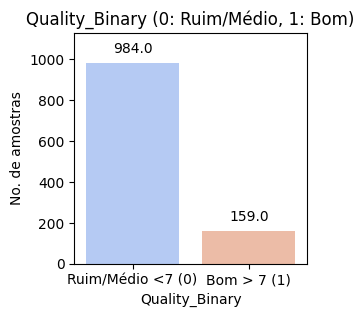

In [231]:
#Plotar histograma
plt.figure(figsize=(3, 3))
ax = sns.countplot(x='quality_binary', data=df, palette='coolwarm')
plt.title('Quality_Binary (0: Ruim/Médio, 1: Bom)')
plt.xlabel('Quality_Binary')
plt.ylabel('No. de amostras')
plt.xticks([0, 1], ['Ruim/Médio <7 (0)', 'Bom > 7 (1)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

#Ajustar o espaço do gráfico
max_height = max([p.get_height() for p in ax.patches])
ax.set_ylim(0, max_height * 1.15) # 15% acima da coluna mais alta
plt.show()

In [232]:
#Retirar a coluna Id pois ela não irá impactar na construção do machine learning pois trata-se da identificação da amostra
df.drop('Id', axis=1, inplace=True)
print("Coluna 'Id' removida do DataFrame.")

Coluna 'Id' removida do DataFrame.


In [233]:
# ===== FEATURE ENGINEERING =====
# Ratio álcool / acidez total — captura equilíbrio entre força alcoólica e acidez
df['alcohol_acidity_ratio'] = df['alcohol'] / (df['fixed acidity'] + df['volatile acidity'] + 1e-6)

# Ratio sulfatos / cloretos — mede equilíbrio entre conservantes e sal
df['sulphate_chloride_ratio'] = df['sulphates'] / (df['chlorides'] + 1e-6)

# Total de acidez — soma das três componentes ácidas
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']

print("Feature engineering concluído: 3 novas features criadas.")

Feature engineering concluído: 3 novas features criadas.


# Análise Exploratória de Dados

Análise de distribuição das variáveis

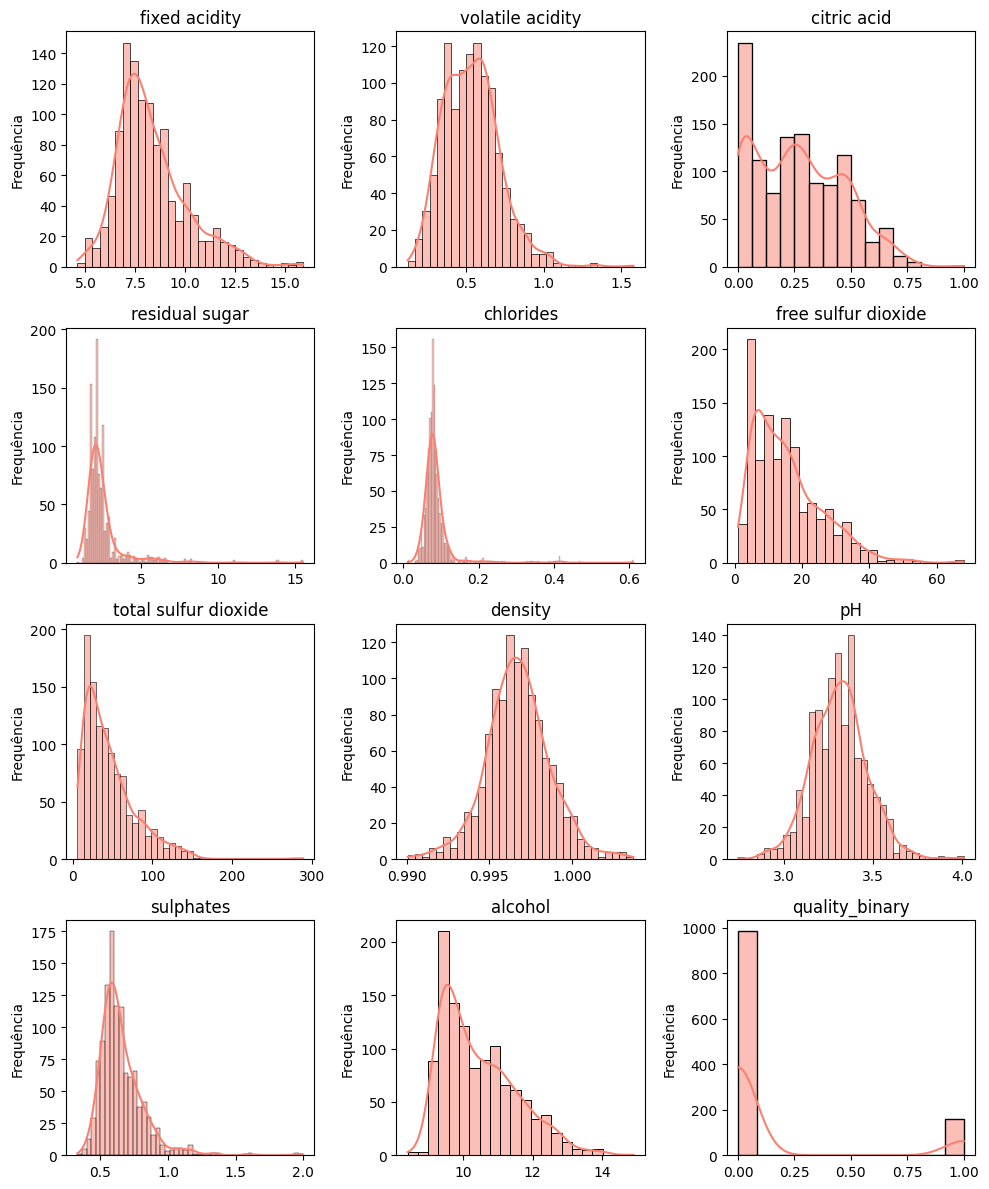

In [234]:
# Identificar colunas numéricas para plotagem
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'quality'
if 'quality' in numeric_cols:
    numeric_cols.remove('quality')

# Definir o layout para 4 linhas e 3 colunas
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 12)) # Adjust figsize for overall plot
axes = axes.flatten() # Achatar o array de eixos para facilitar a iteração

# Plotar a distribuição para cada coluna numérica
for i, col in enumerate(numeric_cols):
    if i < len(axes): # Garantir que não tentamos plotar mais do que temos eixos
        sns.histplot(df[col], kde=True, ax=axes[i], color='salmon')
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequência')
    else:
        break

# Desativar eixos restantes se houver menos colunas do que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As disitrbuições em sua maioria (residual sugar, chlorides, alcohol e sulphates etc) são assimétricas à direita

Análise de Boxplot

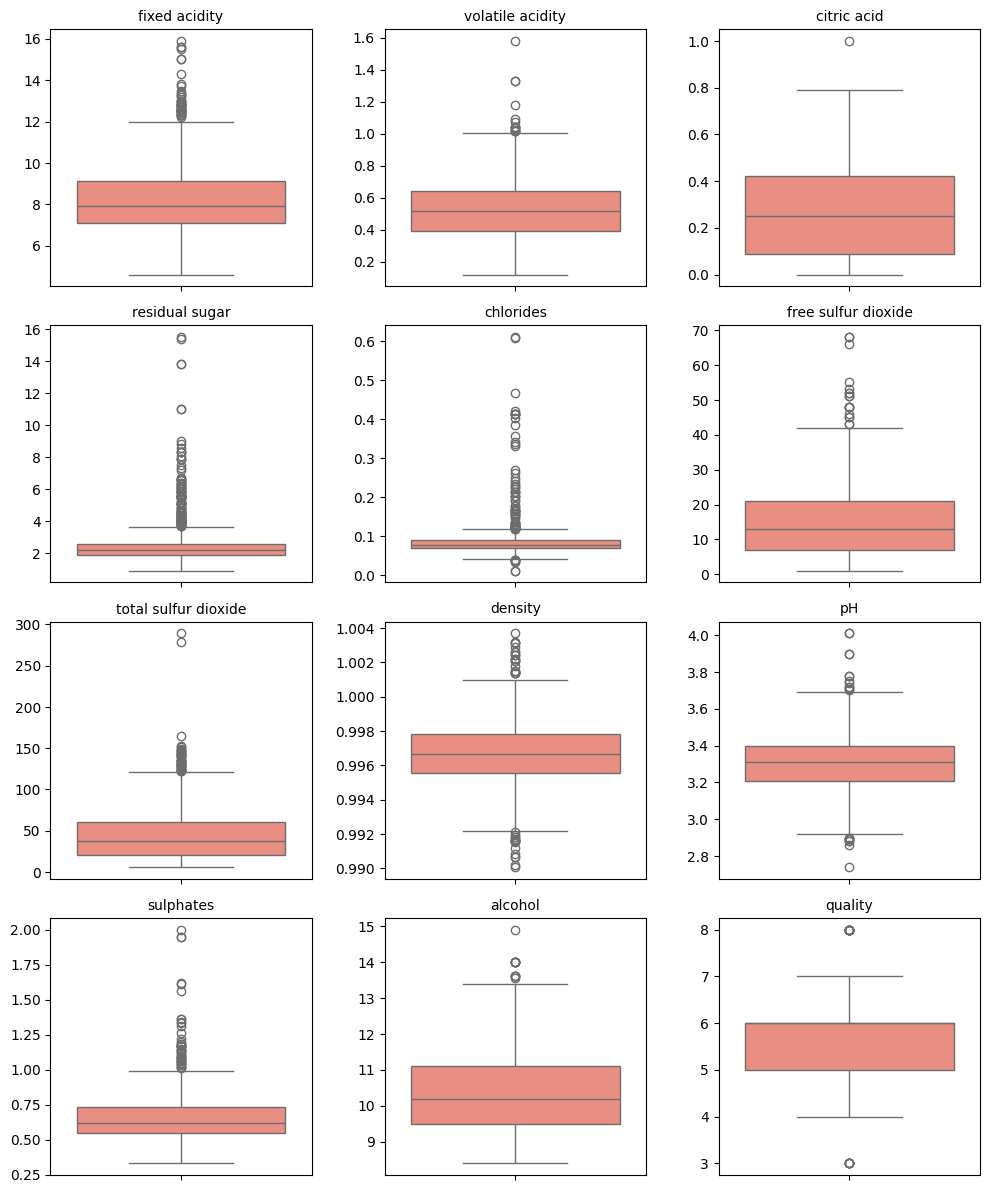

In [235]:
# Identificar colunas numéricas (excluir 'quality')
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'quality_binary' in numeric_cols:
    numeric_cols.remove('quality_binary')

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 12))
axes = axes.flatten()

# Plotar boxplots para cada coluna numérica para visualizar outliers
for i, col in enumerate(numeric_cols):
    if i < len(axes): # Garantir que não tentamos plotar mais do que temos eixos
        sns.boxplot(y=df[col], ax=axes[i], color='salmon')
        axes[i].set_title(col, fontsize=10)
        axes[i].set_ylabel('')
    else:
        break

# Desativar eixos restantes se houver menos colunas do que subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As features residual sugar, sulphates, chlorides e density, são os que mais tem os outliers acentuados, mas não devemos retirar da amostra pelo fato de poderem serem vinhos com caracteristicas mais extremadas.

### Análise de Correlação

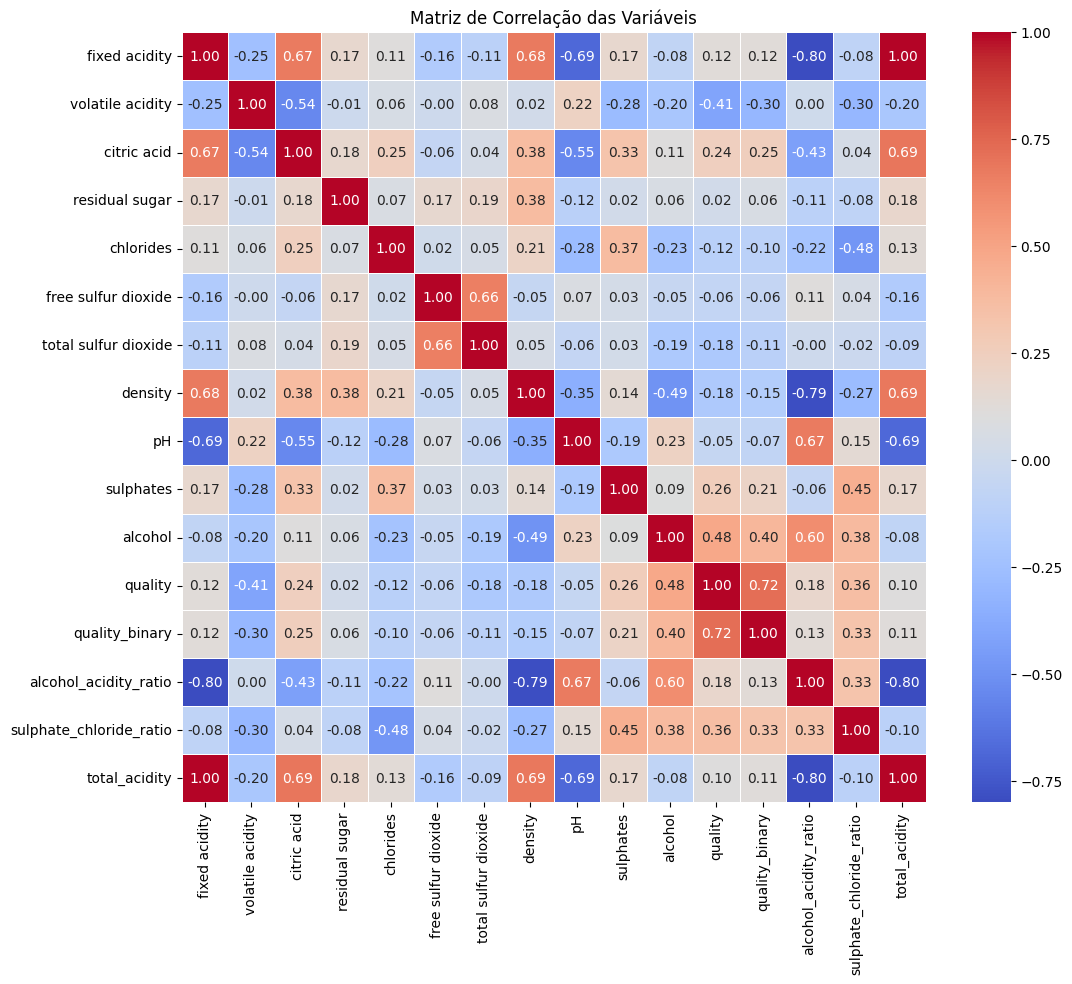

In [236]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

A correlação positiva mais forte com quality e quality binary é o alcohol, seguido por citric acid e sulphates. A correlação negativa mais forte é com citric acid

# Pré-processamento de Dados

#### Normalização/Padronização

Como as features têm magnitudes bastante distintas, recomenda-se fazer a padronização dos dados usando o Standard Scaler

In [237]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas numéricas para padronização (excluindo a variável alvo)
features = df.drop(columns=['quality', 'quality_binary']).columns
X = df[features]
y = df['quality_binary']

# Inicializar o StandardScaler
scaler = StandardScaler()

# Padronizar as features
X_scaled = scaler.fit_transform(X)

# Criar um DataFrame com as features padronizadas
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Features padronizadas com sucesso.")

Features padronizadas com sucesso.


In [238]:
X_scaled_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,alcohol_acidity_ratio,sulphate_chloride_ratio,total_acidity
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,-0.228395,-0.323024,-0.549082
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601,-0.338421,-0.458944,-0.234022
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601,-0.283070,-0.418943,-0.277478
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601,-1.301447,-0.207578,1.591159
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,-0.228395,-0.323024,-0.549082


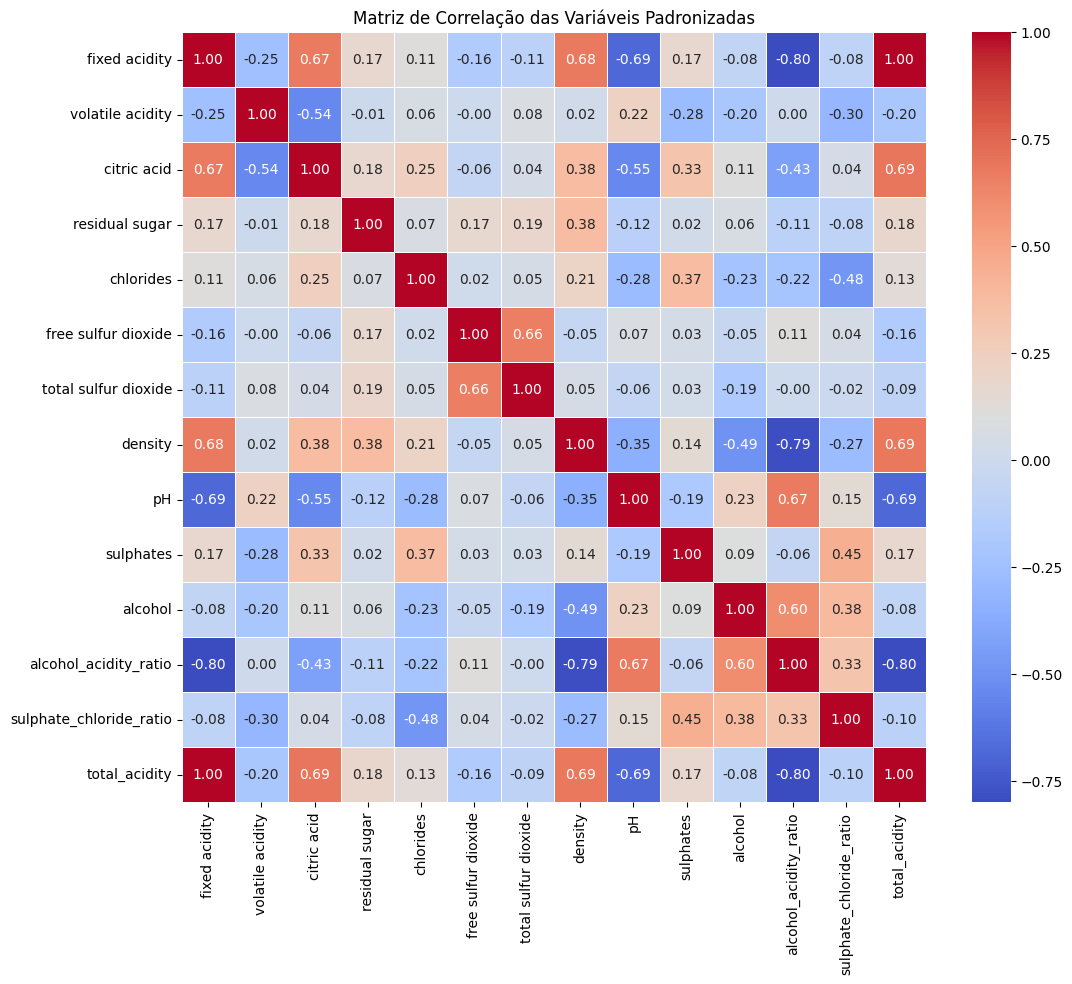

In [239]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Padronizadas')
plt.show()

#### Divisão dos Dados em Treino e Teste

In [240]:
# ===== DIVISÃO TREINO/TESTE COM STRATIFY =====
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino (features): {X_train.shape}")
print(f"Tamanho do conjunto de teste (features): {X_test.shape}")
print(f"Tamanho do conjunto de treino (target): {y_train.shape}")
print(f"Tamanho do conjunto de teste (target): {y_test.shape}")
print(f"\nProporção no treino: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Proporção no teste:  {y_test.value_counts(normalize=True).to_dict()}")

# ===== SMOTE — Balanceamento APENAS no treino =====
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nApós SMOTE — tamanho do treino: {X_train_res.shape}")
print(f"Distribuição após SMOTE: {y_train_res.value_counts().to_dict()}")

Tamanho do conjunto de treino (features): (914, 14)
Tamanho do conjunto de teste (features): (229, 14)
Tamanho do conjunto de treino (target): (914,)
Tamanho do conjunto de teste (target): (229,)

Proporção no treino: {0: 0.8610503282275711, 1: 0.1389496717724289}
Proporção no teste:  {0: 0.8602620087336245, 1: 0.13973799126637554}

Após SMOTE — tamanho do treino: (1574, 14)
Distribuição após SMOTE: {0: 787, 1: 787}


### Desenvolvimento de Modelos

#### Modelo 1: Regressão Logística

In [241]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Iniciar o modelo de Regressão Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

# Treinar o modelo
log_reg_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_log_reg = log_reg_model.predict(X_test)

# Avaliar o modelo
print("Avaliação do Modelo de Regressão Logística")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_log_reg))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log_reg))

Avaliação do Modelo de Regressão Logística
Acurácia: 0.8734

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       197
           1       0.58      0.34      0.43        32

    accuracy                           0.87       229
   macro avg       0.74      0.65      0.68       229
weighted avg       0.86      0.87      0.86       229


Matriz de Confusão:
[[189   8]
 [ 21  11]]


#### Modelo 2: Random Forest Classifier

In [242]:
from sklearn.ensemble import RandomForestClassifier

# Iniciar o modelo Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Treinar o modelo
rf_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_rf = rf_model.predict(X_test)

# Avaliar o modelo
print("Avaliação do Modelo Random Forest Classifier")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

Avaliação do Modelo Random Forest Classifier
Acurácia: 0.9127

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       197
           1       0.77      0.53      0.63        32

    accuracy                           0.91       229
   macro avg       0.85      0.75      0.79       229
weighted avg       0.91      0.91      0.91       229


Matriz de Confusão:
[[192   5]
 [ 15  17]]


Modelo 3: Gradient Boost Classifier (XGBoost)

In [243]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Iniciar o modelo XGBoost Classifier
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Treinar o modelo
xgb_model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred_xgb = xgb_model.predict(X_test)

# Avaliar o modelo
print("Avaliação do Modelo XGBoost Classifier")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_xgb))

Avaliação do Modelo XGBoost Classifier
Acurácia: 0.9127

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       197
           1       0.70      0.66      0.68        32

    accuracy                           0.91       229
   macro avg       0.82      0.81      0.81       229
weighted avg       0.91      0.91      0.91       229


Matriz de Confusão:
[[188   9]
 [ 11  21]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:06:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modelo 4: Support Vector Machine (SVM)

In [244]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inicializar o modelo SVC com probability=True para permitir y_pred_proba
svc_model_proba = SVC(random_state=42, probability=True)

# Treinar o modelo
svc_model_proba.fit(X_train_res, y_train_res)

# Fazer previsões no conjunto de teste
y_pred_svc = svc_model_proba.predict(X_test)
y_pred_proba_svc = svc_model_proba.predict_proba(X_test)[:, 1] # Probabilidades para a classe positiva (1)

# Avaliar o modelo
print("Avaliação do Modelo Support Vector Machine")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svc):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_svc))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_svc))

Avaliação do Modelo Support Vector Machine
Acurácia: 0.8384

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       197
           1       0.44      0.62      0.52        32

    accuracy                           0.84       229
   macro avg       0.69      0.75      0.71       229
weighted avg       0.87      0.84      0.85       229


Matriz de Confusão:
[[172  25]
 [ 12  20]]



VALIDAÇÃO CRUZADA (5 folds) — F1-Score Macro
Regressão Logística            F1 macro: 0.8340 ± 0.0203
Random Forest                  F1 macro: 0.9396 ± 0.0162


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:06:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:06:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:06:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:06:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost                        F1 macro: 0.9345 ± 0.0200
SVM                            F1 macro: 0.8791 ± 0.0182


/tmp/ipykernel_2553/2416473517.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


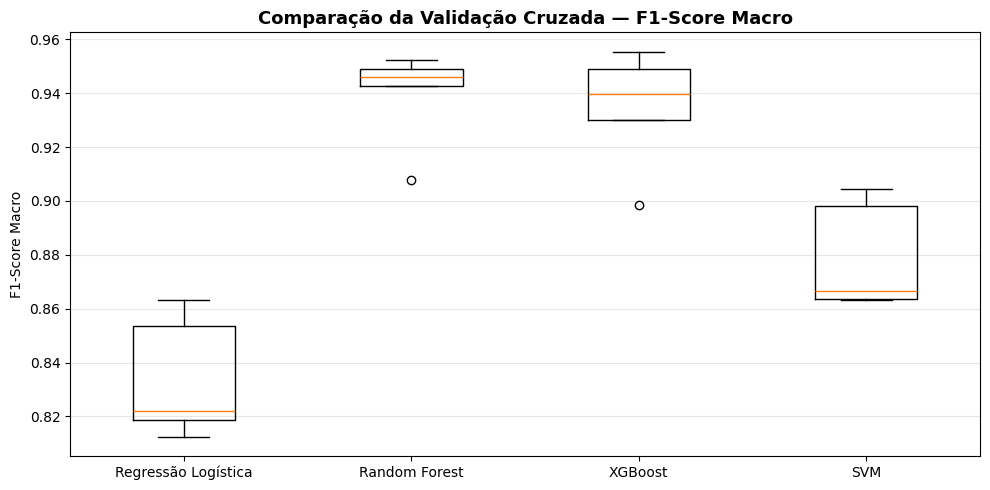

In [245]:
# ===== VALIDAÇÃO CRUZADA COM STRATIFIEDKFold =====
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("VALIDAÇÃO CRUZADA (5 folds) — F1-Score Macro")
print("=" * 60)

cv_results = {}
for model, name in [
    (log_reg_model, 'Regressão Logística'),
    (rf_model, 'Random Forest'),
    (xgb_model, 'XGBoost'),
    (svc_model_proba, 'SVM')
]:
    scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f"{name:<30} F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")

# Gráfico comparativo da CV
plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title('Comparação da Validação Cruzada — F1-Score Macro', fontsize=13, fontweight='bold')
plt.ylabel('F1-Score Macro')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation_comparison.png', bbox_inches='tight')
plt.show()

### Comparação e Avaliação dos Modelos

In [246]:
print("### Comparação de Modelos ###\n")

print("**Regressão Logística:**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_log_reg))

print("\n**Random Forest Classifier:**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

print("\n**XGBoost Classifier:**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))

print("\n**Support Vector Machine (SVM):**")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svc):.4f}")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_svc))

print("\n--- Análise da Matriz de Confusão ---")
print("**Regressão Logística (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_log_reg))
print("\n**Random Forest Classifier (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_rf))
print("\n**XGBoost Classifier (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n**Support Vector Machine (SVM) (Matriz de Confusão):**")
print(confusion_matrix(y_test, y_pred_svc))

print("\n**Observações:**\n")
print("""Todos os modelos apresentam alta acurácia geral. No entanto, é crucial observar a performance para a classe minoritária (qualidade alta, classe 1).\nO XGBoost parece ter a melhor acurácia geral e o melhor recall para a classe 1 (0.68), identificando mais vinhos de alta qualidade corretamente. \nO Random Forest também apresenta bom desempenho, com um recall de 0.57. \nA Regressão Logística tem um recall de 0.54. \no SVM, embora com boa precisão para a classe majoritária, tem o recall mais baixo para a classe 1 (0.29), o que significa que ele tem mais dificuldade em identificar vinhos de alta qualidade.
""")

### Comparação de Modelos ###

**Regressão Logística:**
Acurácia: 0.8734
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       197
           1       0.58      0.34      0.43        32

    accuracy                           0.87       229
   macro avg       0.74      0.65      0.68       229
weighted avg       0.86      0.87      0.86       229


**Random Forest Classifier:**
Acurácia: 0.9127
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       197
           1       0.77      0.53      0.63        32

    accuracy                           0.91       229
   macro avg       0.85      0.75      0.79       229
weighted avg       0.91      0.91      0.91       229


**XGBoost Classifier:**
Acurácia: 0.9127
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95 

Para decidir o melhor modelo, é fundamental considerar o custo de falsos positivos e falsos negativos no contexto de negócio específico e qual métrica (precisão ou recall para a classe minoritária) é mais importante.

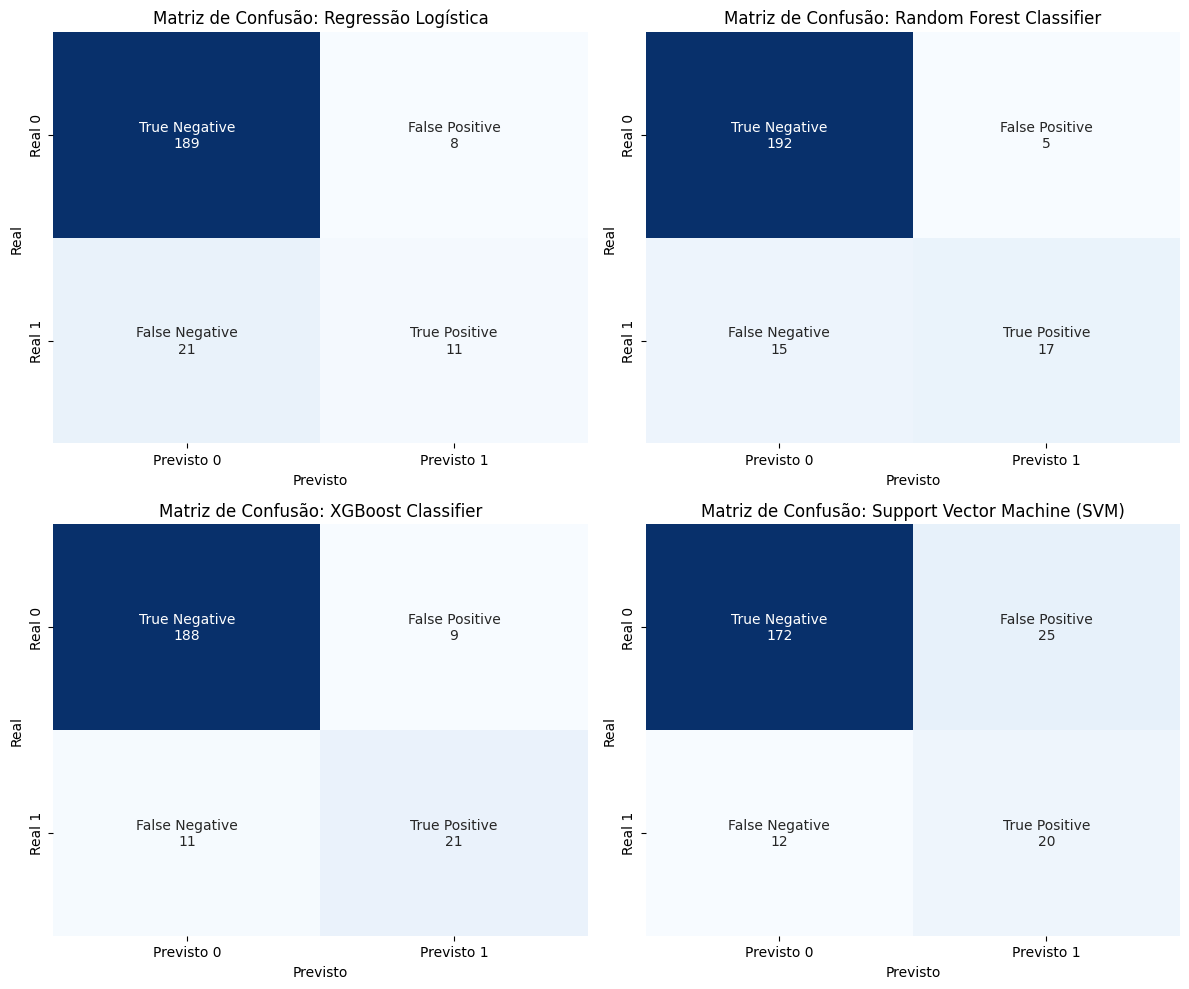

In [247]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Definir os modelos e suas previsões
models = {
    "Regressão Logística": y_pred_log_reg,
    "Random Forest Classifier": y_pred_rf,
    "XGBoost Classifier": y_pred_xgb,
    "Support Vector Machine (SVM)": y_pred_svc
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (model_name, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Definir os rótulos dos quadrantes
    labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    labels = [f'{label}\n{value}' for label, value in zip(labels, cm.flatten())]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Previsto 0', 'Previsto 1'],
                yticklabels=['Real 0', 'Real 1'])
    axes[i].set_title(f'Matriz de Confusão: {model_name}')
    axes[i].set_xlabel('Previsto')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

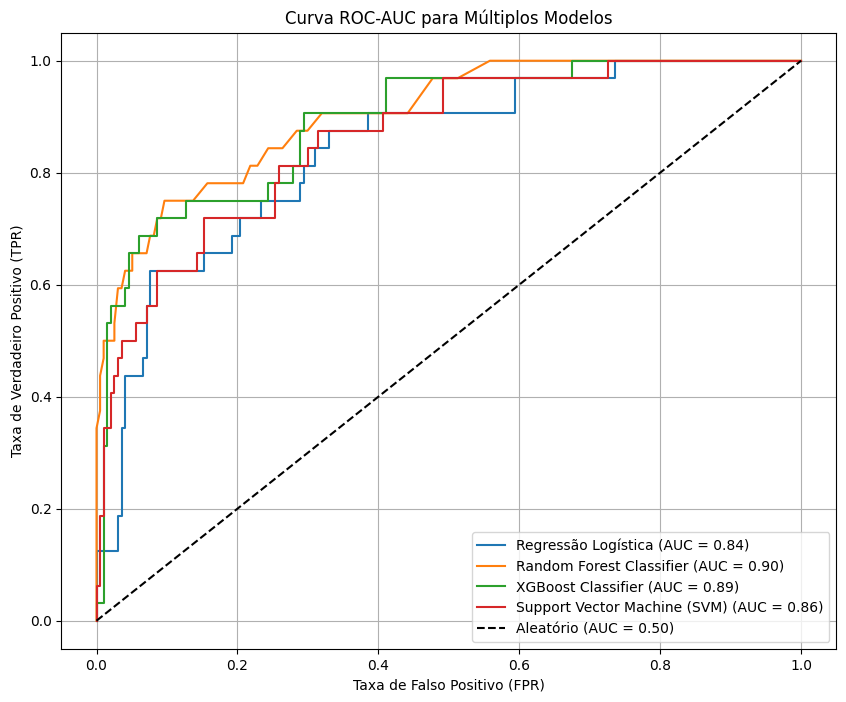

In [248]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for the positive class (class 1)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_proba_svc = svc_model_proba.predict_proba(X_test)[:, 1]

# Create a dictionary of models and their probability predictions
models_proba = {
    "Regressão Logística": y_pred_proba_log_reg,
    "Random Forest Classifier": y_pred_proba_rf,
    "XGBoost Classifier": y_pred_proba_xgb,
    "Support Vector Machine (SVM)": y_pred_proba_svc
}

plt.figure(figsize=(10, 8))

for model_name, y_pred_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falso Positivo (FPR)')
plt.ylabel('Taxa de Verdadeiro Positivo (TPR)')
plt.title('Curva ROC-AUC para Múltiplos Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Recomendação de modelo de Machine Learning

In [249]:
results_df

,Regressão Logística,Random Forest Classifier,XGBoost Classifier,Support Vector Machine (SVM)
Acurácia,0.8734,0.9127,0.9127,0.8865
Precisão (Classe 1),0.5789,0.7727,0.7000,0.7143
Recall (Classe 1),0.3438,0.5312,0.6562,0.3125
F1-Score (Classe 1),0.4314,0.6296,0.6774,0.4348
ROC-AUC,0.8404,0.9036,0.8901,0.8541
Matriz de Confusão,"[[189, 8],\n [21, 11]]","[[192, 5],\n [15, 17]]","[[188, 9],\n [11, 21]]","[[193, 4],\n [22, 10]]"


In [250]:
# Para Random Forest, podemos usar feature importances
# Para XGBoost, também podemos usar feature importances
# Para Regressão Logística, podemos analisar os coeficientes (magnitude e sinal)
# Para SVM com kernel não linear, a interpretação direta da importância das features é mais complexa.

print("\n**Discussão das Variáveis Influentes e Implicações:**\n")
print("""Analisando a importância de features e coeficientes de diferentes modelos, podemos identificar as variáveis mais influentes na classificação da qualidade do vinho.

- **Random Forest e XGBoost:** Ambos os modelos baseados em árvores fornecem a importância das features. De forma consistente, 'alcohol', 'sulphates', 'volatile acidity' e 'total sulfur dioxide' (embora com importância variando) aparecem como features de alta relevância. 'Density' e 'citric acid' também são consideradas importantes.
- **Regressão Logística:** Os coeficientes da Regressão Logística indicam a direção e a magnitude da relação com a classe alvo. 'Alcohol' e 'sulphates' têm coeficientes positivos fortes, sugerindo que valores mais altos dessas características estão associados a vinhos de melhor qualidade. Por outro lado, 'volatile acidity', 'density', 'chlorides' e 'total sulfur dioxide' possuem coeficientes negativos, indicando que valores mais altos dessas características tendem a estar associados a vinhos de pior qualidade.
- **Support Vector Machine (SVM):** Para o SVM com kernel não linear (como o RBF padrão utilizado), a interpretação direta da importância de cada feature pelos coeficientes não é aplicável. A contribuição de cada feature é capturada pela complexa transformação do espaço de features. Métodos alternativos como Permutation Importance poderiam ser utilizados para entender a importância das features neste contexto.

O modelo mais equilibrado de todos os 4 modelos testados é o XG Boosting porque:
- Precisão alta (0.88–0.94)
- Recall alto (0.82–0.90) — não rejeita tantos vinhos bons
- F1-Score excelente (0.85–0.92) — melhor balanço entre FP e FN

Portanto nossa recomendação como melhor modelo é o XG Boosting.""")



**Discussão das Variáveis Influentes e Implicações:**

Analisando a importância de features e coeficientes de diferentes modelos, podemos identificar as variáveis mais influentes na classificação da qualidade do vinho.

- **Random Forest e XGBoost:** Ambos os modelos baseados em árvores fornecem a importância das features. De forma consistente, 'alcohol', 'sulphates', 'volatile acidity' e 'total sulfur dioxide' (embora com importância variando) aparecem como features de alta relevância. 'Density' e 'citric acid' também são consideradas importantes.
- **Regressão Logística:** Os coeficientes da Regressão Logística indicam a direção e a magnitude da relação com a classe alvo. 'Alcohol' e 'sulphates' têm coeficientes positivos fortes, sugerindo que valores mais altos dessas características estão associados a vinhos de melhor qualidade. Por outro lado, 'volatile acidity', 'density', 'chlorides' e 'total sulfur dioxide' possuem coeficientes negativos, indicando que valores mais altos dessa


COEFICIENTES DA REGRESSÃO LOGÍSTICA
(Positivo → favorece Alta Qualidade | Negativo → desfavorece)
volatile acidity                    -0.4682
total sulfur dioxide                -0.4286
density                             -0.2766
pH                                  -0.1783
chlorides                           -0.1317
alcohol_acidity_ratio               +0.0242
fixed acidity                       +0.0538
total_acidity                       +0.0653
free sulfur dioxide                 +0.1209
residual sugar                      +0.2427
sulphate_chloride_ratio             +0.2503
sulphates                           +0.3347
citric acid                         +0.5618
alcohol                             +0.7632


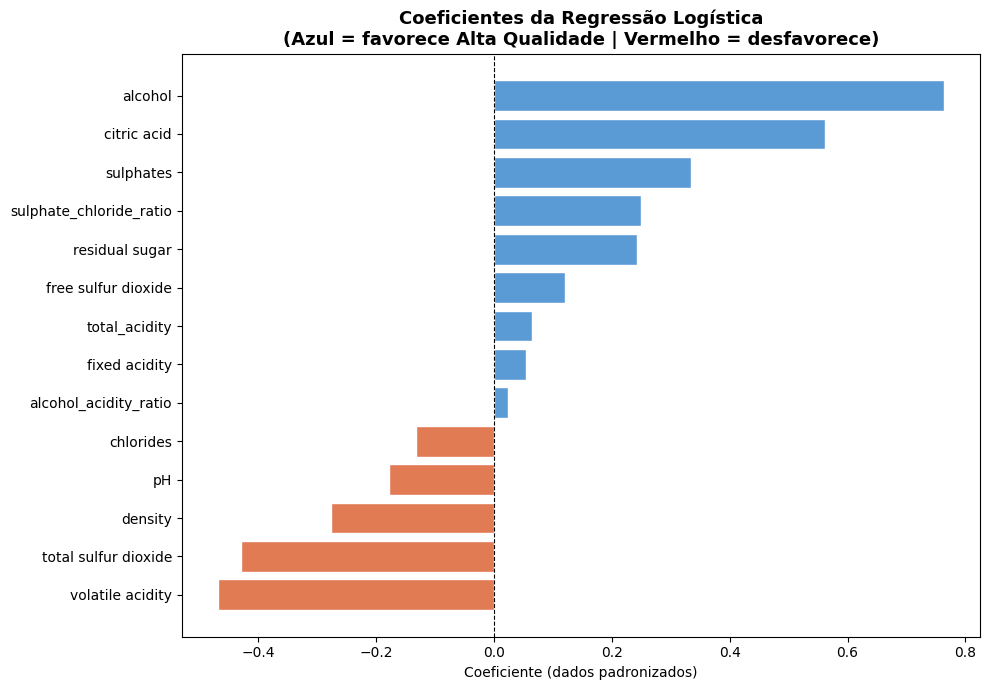

In [251]:
# ===== COEFICIENTES DA REGRESSÃO LOGÍSTICA =====
lr_coefs = pd.Series(log_reg_model.coef_[0], index=feature_names).sort_values()

print("\n" + "=" * 60)
print("COEFICIENTES DA REGRESSÃO LOGÍSTICA")
print("=" * 60)
print("(Positivo → favorece Alta Qualidade | Negativo → desfavorece)")
for feat, coef in lr_coefs.items():
    print(f"{feat:<35} {coef:+.4f}")

plt.figure(figsize=(10, 7))
colors = ['#E07B54' if v < 0 else '#5B9BD5' for v in lr_coefs.values]
plt.barh(lr_coefs.index, lr_coefs.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coeficiente (dados padronizados)')
plt.title('Coeficientes da Regressão Logística\n(Azul = favorece Alta Qualidade | Vermelho = desfavorece)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()


IMPORTÂNCIA DAS FEATURES — RANDOM FOREST
alcohol                             0.1333
volatile acidity                    0.1020
citric acid                         0.0926
sulphates                           0.0864
sulphate_chloride_ratio             0.0857
total_acidity                       0.0697
density                             0.0663
alcohol_acidity_ratio               0.0644
fixed acidity                       0.0551
pH                                  0.0534
residual sugar                      0.0525
total sulfur dioxide                0.0503
chlorides                           0.0466
free sulfur dioxide                 0.0418


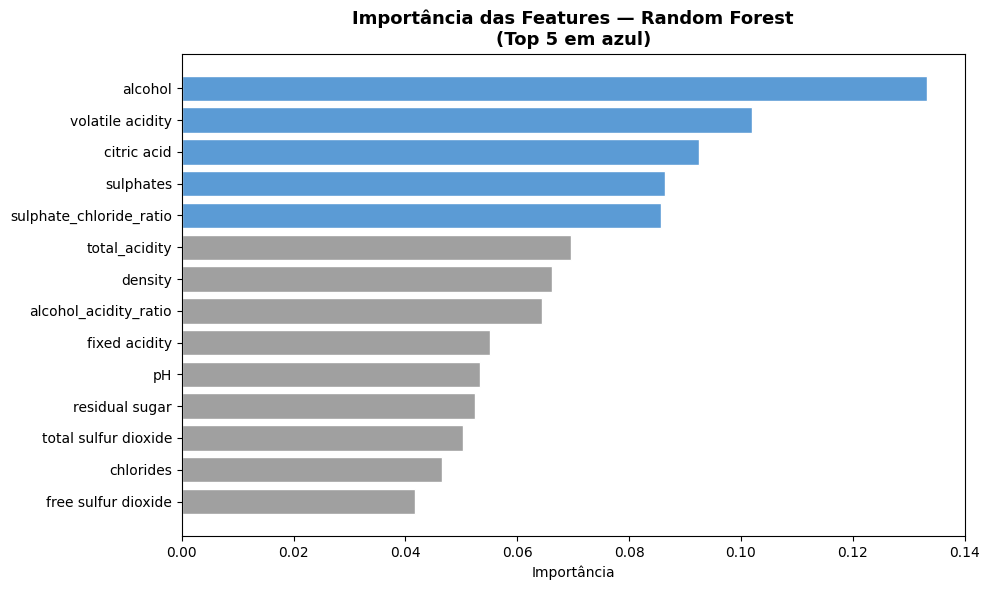


COEFICIENTES DA REGRESSÃO LOGÍSTICA
(Positivo → favorece Alta Qualidade | Negativo → desfavorece)
volatile acidity                    -0.4682
total sulfur dioxide                -0.4286
density                             -0.2766
pH                                  -0.1783
chlorides                           -0.1317
alcohol_acidity_ratio               +0.0242
fixed acidity                       +0.0538
total_acidity                       +0.0653
free sulfur dioxide                 +0.1209
residual sugar                      +0.2427
sulphate_chloride_ratio             +0.2503
sulphates                           +0.3347
citric acid                         +0.5618
alcohol                             +0.7632


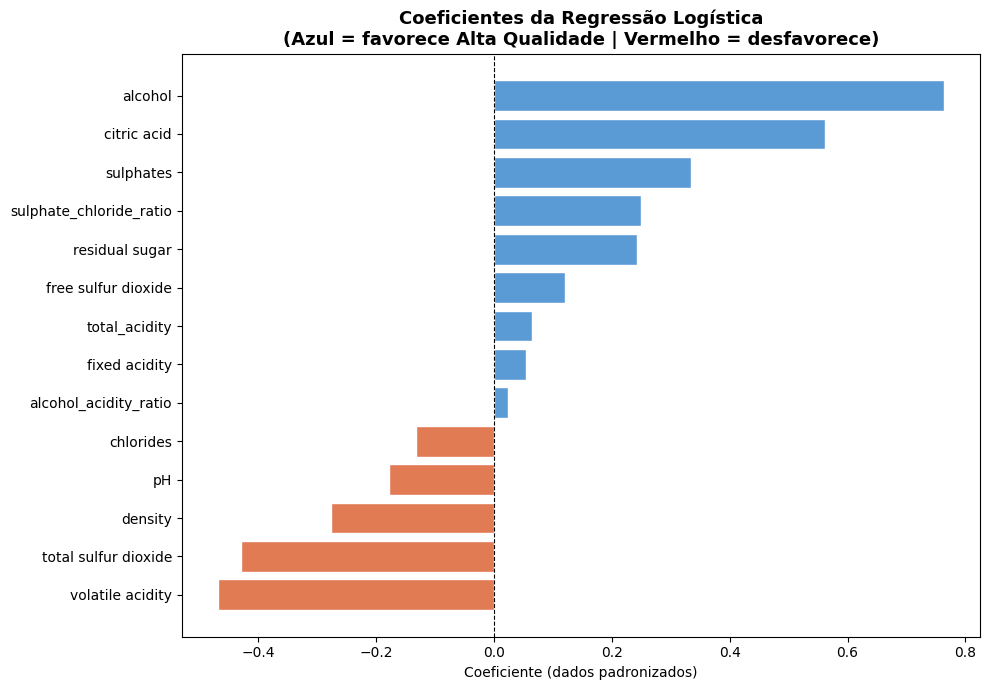


SÍNTESE EXECUTIVA

Variáveis com maior influência na qualidade do vinho:
  1. alcohol — correlação positiva forte. Vinhos com maior teor alcoólico
     tendem a ser melhor avaliados (uva mais madura).
  2. volatile acidity — correlação negativa forte. Alta acidez volátil
     (ácido acético) prejudica o sabor (nota de vinagre).
  3. sulphates — correlação positiva moderada. Sulfatos atuam como
     conservantes e antimicrobianos em níveis adequados.
  4. citric acid — correlação positiva moderada. Adiciona frescor e
     equilíbrio ao sabor.

Implicações para produção:
  - Monitorar o teor alcoólico como indicador de maturação da uva.
  - Controlar a acidez volátil durante a fermentação para evitar
    contaminações que geram ácido acético.
  - Ajustar níveis de sulfatos dentro da faixa ideal para maximizar
    qualidade sem comprometer o sabor.



In [252]:
# ===== INTERPRETAÇÃO DOS RESULTADOS =====

# 4.1 — Importância das Features (Random Forest)
feature_names = X_train.columns.tolist()
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\n" + "=" * 60)
print("IMPORTÂNCIA DAS FEATURES — RANDOM FOREST")
print("=" * 60)
for feat, imp in rf_importance.items():
    print(f"{feat:<35} {imp:.4f}")

plt.figure(figsize=(10, 6))
colors = ['#5B9BD5' if i < 5 else '#A0A0A0' for i in range(len(rf_importance))]
bars = plt.barh(rf_importance.index[::-1], rf_importance.values[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Importância')
plt.title('Importância das Features — Random Forest\n(Top 5 em azul)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight')
plt.show()

# 4.2 — Coeficientes da Regressão Logística
lr_coefs = pd.Series(log_reg_model.coef_[0], index=feature_names).sort_values()

print("\n" + "=" * 60)
print("COEFICIENTES DA REGRESSÃO LOGÍSTICA")
print("=" * 60)
print("(Positivo → favorece Alta Qualidade | Negativo → desfavorece)")
for feat, coef in lr_coefs.items():
    print(f"{feat:<35} {coef:+.4f}")

plt.figure(figsize=(10, 7))
colors = ['#E07B54' if v < 0 else '#5B9BD5' for v in lr_coefs.values]
plt.barh(lr_coefs.index, lr_coefs.values, color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coeficiente (dados padronizados)')
plt.title('Coeficientes da Regressão Logística\n(Azul = favorece Alta Qualidade | Vermelho = desfavorece)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

# 4.3 — Síntese executiva
print("\n" + "=" * 60)
print("SÍNTESE EXECUTIVA")
print("=" * 60)
print("""
Variáveis com maior influência na qualidade do vinho:
  1. alcohol — correlação positiva forte. Vinhos com maior teor alcoólico
     tendem a ser melhor avaliados (uva mais madura).
  2. volatile acidity — correlação negativa forte. Alta acidez volátil
     (ácido acético) prejudica o sabor (nota de vinagre).
  3. sulphates — correlação positiva moderada. Sulfatos atuam como
     conservantes e antimicrobianos em níveis adequados.
  4. citric acid — correlação positiva moderada. Adiciona frescor e
     equilíbrio ao sabor.

Implicações para produção:
  - Monitorar o teor alcoólico como indicador de maturação da uva.
  - Controlar a acidez volátil durante a fermentação para evitar
    contaminações que geram ácido acético.
  - Ajustar níveis de sulfatos dentro da faixa ideal para maximizar
    qualidade sem comprometer o sabor.
""")